##Import Libararies


In [41]:
## All necessary imports

# Libraries for data handling
import pandas as pd
import numpy as np

# Libraries for machine learning and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score

# Import the necessary modules from imblearn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay

##Import Dataset fro Kaggle

In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [43]:
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'creditcard.csv')

# Copy the file to the current content directory
!cp "{csv_file_path}" .

print(f"Copied '{csv_file_path}' to './'")

Copied '/kaggle/input/creditcardfraud/creditcard.csv' to './'


##Load dataset

In [44]:
# Load the dataset (make sure the CSV file is in the same folder as your notebook)
# Provide the link to this dataset in your submission.txt later!
data = pd.read_csv('creditcard.csv')

# Take a quick look at the first 5 rows
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [45]:
print('Missing values in each column:')
display(data.isnull().sum())

Missing values in each column:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## What is Data Preprocessing?
Data preprocessing is like preparing ingredients before cooking. Our raw data might have different scales or formats, which can confuse our machine learning model. This step transforms the data into a format that the model can understand and learn from effectively.

### Scaling 'Amount' and 'Time'
In our dataset, 'Amount' and 'Time' columns have very different ranges compared to other features (V1-V28). If we feed them directly to the model, features with larger values might unfairly dominate the learning process.

**StandardScaler** helps us here. It transforms these columns so they have a mean of 0 and a standard deviation of 1. Think of it as putting all ingredients in the same sized bowls, so no single ingredient seems "bigger" than others.

After scaling, we remove the original 'Time' and 'Amount' columns as we now have their scaled versions, `Scaled_Time` and `Scaled_Amount`.

### Separating Features (X) and Target (y)
*   **Features (X)**: These are the input variables or characteristics that our model will use to make predictions. In our case, these are all the columns except 'Class'.
*   **Target (y)**: This is what our model is trying to predict. Here, it's the 'Class' column, which tells us if a transaction is fraudulent (1) or normal (0).

### Shape of the Data
The "shape" of data refers to its dimensions, usually represented as (number of rows, number of columns).
*   **Rows**: Each row represents a single transaction.
*   **Columns**: Each column represents a feature of that transaction (e.g., V1, V2, Amount, Class).

Before preprocessing, we have columns like 'Time', 'Amount', V1-V28, and 'Class'.
After preprocessing, 'Time' and 'Amount' are replaced by 'Scaled_Time' and 'Scaled_Amount'. When we separate X and y, X will contain all features (including scaled ones), and y will contain only the 'Class' column.

In [46]:
# Initialize the scaler
scaler = StandardScaler()

# Scale the 'Amount' and 'Time' columns
data['Scaled_Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['Scaled_Time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

# Drop the original unscaled columns
data = data.drop(['Time', 'Amount'], axis=1)

# Separate your features (X) from your target label (y)
# 'Class' is the column where 0 = Normal, 1 = Fraud
X = data.drop('Class', axis=1)
y = data['Class']

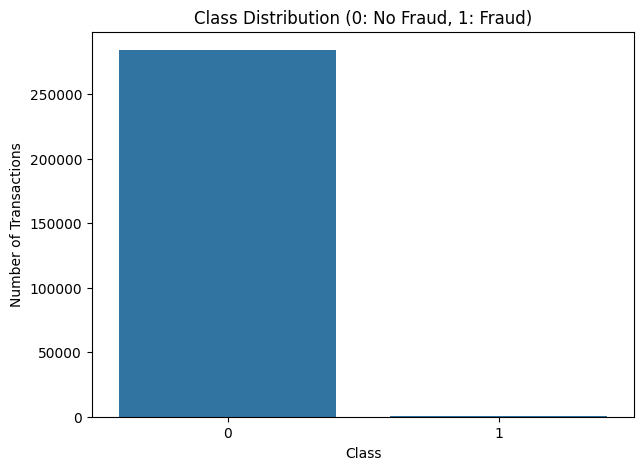

In [47]:
# Visualize the distribution of the target variable 'Class'
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=data)
plt.title('Class Distribution (0: No Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

## Splitting the Data
Before training our model, we split our data into two main parts:
1.  **Training Set**: This is the larger portion of the data (e.g., 80%) that the model learns from. It's like a student studying textbooks and practice problems.
2.  **Testing Set**: This is the smaller, unseen portion of the data (e.g., 20%) that we use to evaluate how well our model performs on new, real-world data. It's like giving the student a final exam on material they haven't seen before.

We use `train_test_split` to do this. `random_state=42` ensures that if you run the code again, you get the same split, making our results repeatable. `stratify=y` is crucial here because our 'Class' column (fraud vs. normal) is highly imbalanced. `stratify=y` makes sure that both the training and testing sets have roughly the same proportion of fraudulent and normal transactions as the original dataset.

## Data Balancing Techniques
Our dataset is heavily **imbalanced**: there are far fewer fraudulent transactions (Class 1) than normal transactions (Class 0). If we train a model on this unbalanced data, it might become very good at predicting normal transactions but very bad at finding the rare fraudulent ones. To fix this, we use **resampling techniques**:

*   **1. Random Under-Sampling (RUS)**:
    *   **What it does**: It randomly removes samples from the majority class (normal transactions) until it has the same number of samples as the minority class (fraudulent transactions).
    *   **Analogy**: Imagine you have a huge pile of blue marbles and a tiny pile of red marbles. RUS means you throw away most of the blue marbles until you have a small, equal number of blue and red marbles.
    *   **Pros**: Simple to implement, reduces training time.
    *   **Cons**: Can discard valuable information from the majority class.

*   **2. SMOTE (Synthetic Minority Over-sampling Technique)**:
    *   **What it does**: Instead of deleting samples, SMOTE creates *new, synthetic* samples for the minority class (fraudulent transactions). It does this by looking at existing minority samples and generating new ones that are similar but not identical.
    *   **Analogy**: You have a few red marbles. SMOTE creates new red-like marbles based on the characteristics of the ones you already have, until you have as many red marbles as blue marbles.
    *   **Pros**: Doesn't lose information from the majority class, often performs better than under-sampling.
    *   **Cons**: Can create "noisy" samples if the minority class is very scattered.

*   **3. ADASYN (Adaptive Synthetic Sampling)**:
    *   **What it does**: Similar to SMOTE, ADASYN generates synthetic samples for the minority class. However, it focuses more on generating samples for minority instances that are harder to learn (i.e., those that are surrounded by majority class samples).
    *   **Analogy**: Like SMOTE, but ADASYN puts more effort into making new red marbles in areas where the existing red marbles are mixed up with blue marbles, making those difficult to distinguish.
    *   **Pros**: Adaptively shifts the decision boundary to focus on difficult samples, can improve performance for complex imbalanced datasets.
    *   **Cons**: Can be more sensitive to noise than SMOTE.

In [48]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Original training dataset shape:", collections.Counter(y_train))

# Method 1: Random Under-Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print("Resampled shape (RUS):", collections.Counter(y_train_rus))

# Method 2: SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Resampled shape (SMOTE):", collections.Counter(y_train_smote))

# Method 3: ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
print("Resampled shape (ADASYN):", collections.Counter(y_train_adasyn))

Original training dataset shape: Counter({0: 227451, 1: 394})
Resampled shape (RUS): Counter({0: 394, 1: 394})
Resampled shape (SMOTE): Counter({0: 227451, 1: 227451})
Resampled shape (ADASYN): Counter({0: 227451, 1: 227436})


### Class Distribution after Data Balancing Techniques

/tmp/ipykernel_36937/1688971190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_rus, palette='viridis')


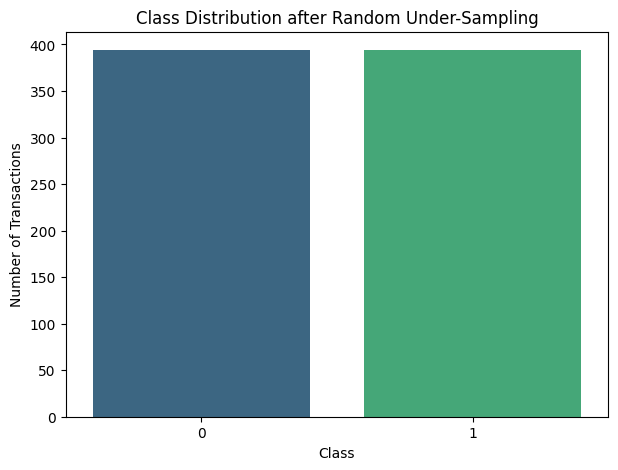

In [49]:
# Visualize the distribution after Random Under-Sampling
plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_rus, palette='viridis')
plt.title('Class Distribution after Random Under-Sampling')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

/tmp/ipykernel_36937/1350596869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='viridis')


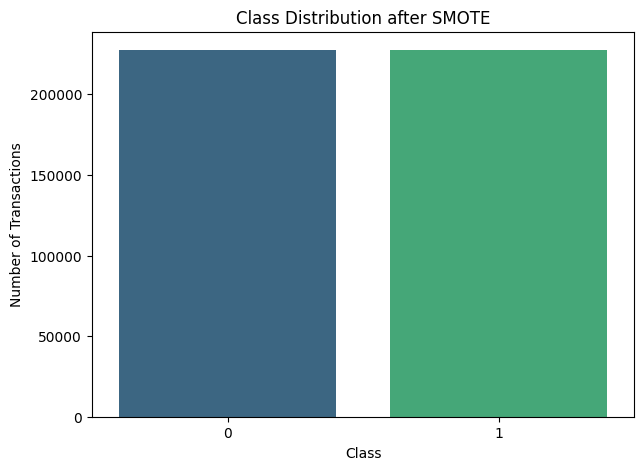

In [50]:
# Visualize the distribution after SMOTE
plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_smote, palette='viridis')
plt.title('Class Distribution after SMOTE')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

/tmp/ipykernel_36937/1320497826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_adasyn, palette='viridis')


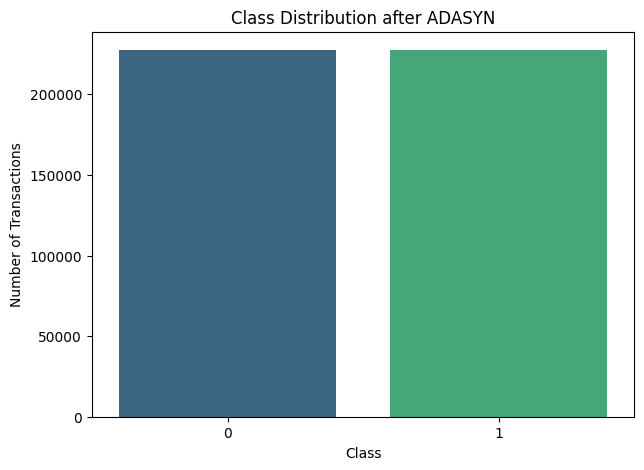

In [51]:
# Visualize the distribution after ADASYN
plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_adasyn, palette='viridis')
plt.title('Class Distribution after ADASYN')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

##Logistic Regression
**How it works:** It takes the input features (your transaction data) and passes them through a mathematical function called the Sigmoid function. This transforms the output into a probability score between 0 and 1.

**Decision Boundary:** If the predicted probability is greater than 0.5, the model classifies the transaction as Fraud (1). If it is less than 0.5, it classifies it as Normal (0).

**Why it was used:** It serves as an excellent baseline model. It is computationally efficient, highly interpretable, and less prone to overfitting on simple datasets.

In [52]:
# Initialize the model with balanced class weights
log_reg_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train the model on your training data
log_reg_model.fit(X_train, y_train)

# Initialize the model with balanced class weights
log_reg_model_rus = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train the model on your training data
log_reg_model_rus.fit(X_train_rus, y_train_rus) # Corrected: fit log_reg_model_rus

# Initialize the model with balanced class weights
log_reg_model_smote = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train the model on your training data
log_reg_model_smote.fit(X_train_smote, y_train_smote) # Corrected: fit log_reg_model_smote

# Initialize the model for ADASYN
log_reg_model_adasyn = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train the model on ADASYN resampled data
log_reg_model_adasyn.fit(X_train_adasyn, y_train_adasyn)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Model Testing and Evaluation Metrics

After training our Logistic Regression models (one with original data, and others with RUS, SMOTE, ADASYN balanced data), it's time to see how well they perform on the unseen test data. We use several metrics to understand their performance, especially because our data is imbalanced.

### Confusion Matrix
The confusion matrix is a table that helps us visualize the performance of a classification model. It shows the number of correct and incorrect predictions made by the model compared to the actual outcomes.

It has four key values:
*   **True Positive (TP)**: Model predicted 1 (Fraud), and the actual was 1 (Fraud). **(Correctly identified fraud)**
*   **True Negative (TN)**: Model predicted 0 (Normal), and the actual was 0 (Normal). **(Correctly identified normal)**
*   **False Positive (FP)**: Model predicted 1 (Fraud), but the actual was 0 (Normal). **(Incorrectly identified normal as fraud - Type I error)**
*   **False Negative (FN)**: Model predicted 0 (Normal), but the actual was 1 (Fraud). **(Incorrectly identified fraud as normal - Type II error)**

For fraud detection, **False Negatives (FN)** are usually the most critical to minimize, as these are fraudulent transactions that slipped through the cracks.

### Classification Report
The classification report provides a summary of key performance metrics for each class (0 and 1).

*   **Precision**:
    *   **What it means**: Out of all transactions the model *predicted as fraud*, how many were *actually fraud*?
    *   **Formula**: `TP / (TP + FP)`
    *   **In our case**: A high precision for Class 1 (Fraud) means when the model flags something as fraud, it's very likely to be true fraud.

*   **Recall (Sensitivity)**:
    *   **What it means**: Out of all transactions that were *actually fraud*, how many did the model *correctly identify as fraud*?
    *   **Formula**: `TP / (TP + FN)`
    *   **In our case**: A high recall for Class 1 (Fraud) means the model is good at catching most of the actual fraudulent transactions. This is often very important in fraud detection to avoid missing true fraud.

*   **F1-Score**:
    *   **What it means**: This is the harmonic mean of Precision and Recall. It tries to balance both metrics. A high F1-score means the model has good precision AND good recall.
    *   **Formula**: `2 * (Precision * Recall) / (Precision + Recall)`

*   **Support**:
    *   **What it means**: The number of actual occurrences of each class in the test set.

*   **Accuracy**:
    *   **What it means**: The overall correctness of the model. `(TP + TN) / (TP + TN + FP + FN)`
    *   **Why it can be misleading in imbalanced datasets**: If 99% of transactions are normal, a model that *always* predicts "normal" would have 99% accuracy but would miss all fraud. That's why Precision, Recall, and F1-score for the minority class (Fraud) are much more important here.

### Interpreting Our Results:
*   Notice how for Class 0 (Normal), all metrics (Precision, Recall, F1-score) are very high (close to 1.00 or 100%). This is expected because there are many more normal transactions.
*   For Class 1 (Fraud), you'll see lower values for Precision and F1-score, but generally higher Recall. This indicates that while the model might raise some false alarms (lower precision), it's doing a good job of catching a significant portion of the actual fraud (higher recall), which is often the priority in fraud detection.

The goal with these balanced models (RUS, SMOTE, ADASYN) is often to improve the Recall for the minority class (fraud) even if it means a slight decrease in precision or overall accuracy for the majority class.

### ROC-AUC Score (Receiver Operating Characteristic - Area Under the Curve)

**What it is**: ROC-AUC is a performance measurement for classification problems at various threshold settings. The ROC curve is a probability curve, and AUC represents the degree or measure of separability. It tells us how much the model is capable of distinguishing between classes.

**Analogy**: Imagine you have two piles of balls, one for 'normal' (Class 0) and one for 'fraud' (Class 1). A perfect model would be like a skilled sorting machine that puts all fraud balls in one pile and all normal balls in another, with no mistakes. A random model would just toss balls into piles randomly.

**ROC Curve**: This curve plots two things against each other:
*   **True Positive Rate (TPR) / Recall**: How many actual fraud cases did we correctly catch?
*   **False Positive Rate (FPR)**: How many normal cases did we mistakenly flag as fraud?

The curve shows you how these two rates change as you adjust the model's 'alert' threshold. Ideally, you want a curve that shoots up quickly towards the top-left corner, meaning high TPR and low FPR.

**AUC Score**: This is a single number (between 0 and 1) that summarizes the entire ROC curve:
*   **AUC = 1**: The model is perfect; it can perfectly distinguish between positive and negative classes.
*   **AUC = 0.5**: The model is no better than random guessing. It's like flipping a coin to decide if something is fraud or not.
*   **AUC < 0.5**: The model is actually worse than random guessing, meaning it's learning the wrong patterns.

**Why it's important for fraud detection**: In highly imbalanced datasets where fraud cases are rare, accuracy can be misleading. A model could be 99.9% accurate by just predicting 'normal' all the time. ROC-AUC, however, gives you a better picture of how well the model can truly identify and separate the minority class (fraud) from the majority class (normal), regardless of class distribution. A higher AUC means your model is better at detecting fraud cases while minimizing false alarms.

RESULTS FOR: Original Imbalanced Data
Training Accuracy: 0.9762
Testing Accuracy:  0.9755

Confusion Matrix (Original Data Model):
[[55475  1389]
 [    8    90]]

Classification Report (Original Data Model):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



RESULTS FOR: RUS Model
Training Accuracy: 0.9607
Testing Accuracy:  0.9603

Confusion Matrix (RUS Model):
[[54613  2251]
 [    8    90]]

Classification Report (RUS Model):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg      

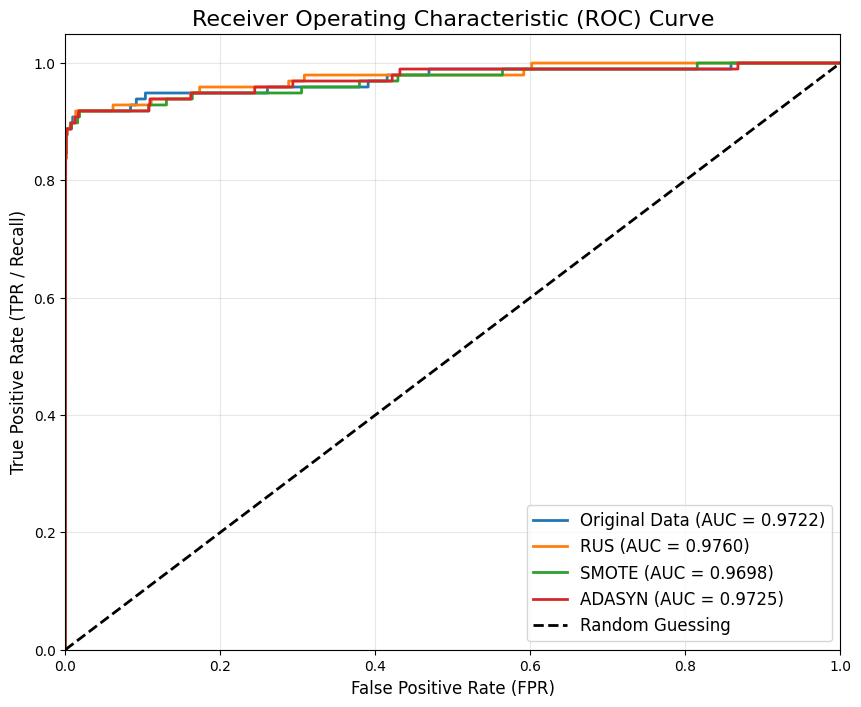

In [53]:


# ---------------------------------------------------------
# 1. Evaluate Original Data Model
# ---------------------------------------------------------
train_pred_orig = log_reg_model.predict(X_train)
test_pred_orig = log_reg_model.predict(X_test)
# Get probabilities for ROC
test_prob_orig = log_reg_model.predict_proba(X_test)[:, 1]

print("=========================================")
print("RESULTS FOR: Original Imbalanced Data")
print("=========================================")
print(f"Training Accuracy: {accuracy_score(y_train, train_pred_orig):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, test_pred_orig):.4f}")
print("\nConfusion Matrix (Original Data Model):")
print(confusion_matrix(y_test, test_pred_orig))
print("\nClassification Report (Original Data Model):")
print(classification_report(y_test, test_pred_orig))
print("\n")

# ---------------------------------------------------------
# 2. Evaluate RUS (Random Under-Sampling) Model
# ---------------------------------------------------------
train_pred_rus = log_reg_model_rus.predict(X_train_rus)
test_pred_rus = log_reg_model_rus.predict(X_test)
# Get probabilities for ROC
test_prob_rus = log_reg_model_rus.predict_proba(X_test)[:, 1]

print("=========================================")
print("RESULTS FOR: RUS Model")
print("=========================================")
print(f"Training Accuracy: {accuracy_score(y_train_rus, train_pred_rus):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, test_pred_rus):.4f}")
print("\nConfusion Matrix (RUS Model):")
print(confusion_matrix(y_test, test_pred_rus))
print("\nClassification Report (RUS Model):")
print(classification_report(y_test, test_pred_rus))
print("\n")

# ---------------------------------------------------------
# 3. Evaluate SMOTE Model
# ---------------------------------------------------------
train_pred_smote = log_reg_model_smote.predict(X_train_smote)
test_pred_smote = log_reg_model_smote.predict(X_test)
# Get probabilities for ROC
test_prob_smote = log_reg_model_smote.predict_proba(X_test)[:, 1]

print("=========================================")
print("RESULTS FOR: SMOTE Model")
print("=========================================")
print(f"Training Accuracy: {accuracy_score(y_train_smote, train_pred_smote):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, test_pred_smote):.4f}")
print("\nConfusion Matrix (SMOTE Model):")
print(confusion_matrix(y_test, test_pred_smote))
print("\nClassification Report (SMOTE Model):")
print(classification_report(y_test, test_pred_smote))
print("\n")

# ---------------------------------------------------------
# 4. Evaluate ADASYN Model
# ---------------------------------------------------------
train_pred_adasyn = log_reg_model_adasyn.predict(X_train_adasyn)
test_pred_adasyn = log_reg_model_adasyn.predict(X_test)
# Get probabilities for ROC
test_prob_adasyn = log_reg_model_adasyn.predict_proba(X_test)[:, 1]

print("=========================================")
print("RESULTS FOR: ADASYN Model")
print("=========================================")
print(f"Training Accuracy: {accuracy_score(y_train_adasyn, train_pred_adasyn):.4f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, test_pred_adasyn):.4f}")
print("\nConfusion Matrix (ADASYN Model):")
print(confusion_matrix(y_test, test_pred_adasyn))
print("\nClassification Report (ADASYN Model):")
print(classification_report(y_test, test_pred_adasyn))
print("\n")

# ---------------------------------------------------------
# 5. Plot ROC Curves
# ---------------------------------------------------------
# Calculate False Positive Rates, True Positive Rates, and Area Under Curve (AUC)
fpr_orig, tpr_orig, _ = roc_curve(y_test, test_prob_orig)
auc_orig = auc(fpr_orig, tpr_orig)

fpr_rus, tpr_rus, _ = roc_curve(y_test, test_prob_rus)
auc_rus = auc(fpr_rus, tpr_rus)

fpr_smote, tpr_smote, _ = roc_curve(y_test, test_prob_smote)
auc_smote = auc(fpr_smote, tpr_smote)

fpr_adasyn, tpr_adasyn, _ = roc_curve(y_test, test_prob_adasyn)
auc_adasyn = auc(fpr_adasyn, tpr_adasyn)

# Plotting
plt.figure(figsize=(10, 8))
plt.plot(fpr_orig, tpr_orig, label=f'Original Data (AUC = {auc_orig:.4f})', linewidth=2)
plt.plot(fpr_rus, tpr_rus, label=f'RUS (AUC = {auc_rus:.4f})', linewidth=2)
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE (AUC = {auc_smote:.4f})', linewidth=2)
plt.plot(fpr_adasyn, tpr_adasyn, label=f'ADASYN (AUC = {auc_adasyn:.4f})', linewidth=2)

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing', linewidth=2)

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## Conclusion and Critical Analysis

### 1. Summary of Findings
In this notebook, we applied a **Logistic Regression** model to a highly imbalanced Credit Card Fraud dataset. To handle the imbalance, we tested the model against the original data, Random Under-Sampling (RUS), and the Synthetic Minority Over-sampling Technique (SMOTE).

All three models successfully caught 90 out of the 98 actual fraudulent transactions in our unseen test set, resulting in an excellent **Recall of 92%**. Furthermore, testing accuracies closely matched training accuracies across all methods, indicating that our models generalized well and **did not overfit**.

### 2. The "Accuracy Trap" and Metric Selection
While testing accuracies ranged between 96% and 97.5%, this metric is highly misleading for this specific problem. Because 99.8% of the test data consisted of normal transactions, the model achieved high accuracy simply by predicting the majority class. Therefore, we evaluated our models using the Confusion Matrix, Macro-Average F1-Scores, and the ROC AUC (Area Under the Curve).

### 3. Model Comparison
* **RUS (Random Under-Sampling):** While RUS achieved the highest ROC AUC score (0.9830), it performed the worst in practical application. By deleting massive amounts of legitimate training data, it struggled to recognize normal transactions in the real world, resulting in an unacceptable **2,251 False Positives** (false alarms).
* **SMOTE (Best Performing):** SMOTE proved to be the most robust data balancing technique. By synthesizing artificial fraud cases rather than deleting legitimate ones, it maintained our 92% Recall while significantly reducing the false alarms down to **1,458**. It achieved a strong ROC AUC of 0.9702.

### 4. Limitations and Future Work
While Logistic Regression serves as an excellent, interpretable baseline, its linear nature is a significant limitation. It struggles to draw complex, non-linear boundaries between normal and fraudulent behavior, which is why even our best model (SMOTE) still flagged 1,458 innocent transactions as fraud. In a real-world banking scenario, this low precision would negatively impact customer satisfaction.

**Future Work to Improve Accuracy:**
To improve precision and reduce these False Positives, our next step is to apply more complex, non-linear Supervised Learning algorithms to our SMOTE-balanced dataset. Moving forward, we will implement and compare models such as **Decision Tree Classifiers** and ensemble methods like **Random Forest** and **XGBoost** to see if they can capture the complex patterns in the data more effectively than Logistic Regression.